In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# 1. IMPORTING LIBRARIES


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import xgboost as xgb
import lightgbm as lgb

## Appendix - Milestones


In [3]:
#Milestone-2
#Q1 In the context of text preprocessing for NLP, which condition must be checked in addition to NaN values when assessing missingness in the comment column of train.csv?
#Ans = Presence of empty or whitespace-only strings.

#Q2 Convert the created_date column into datetime objects. Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string?
#Ans = 
#train["created_date"] = pd.to_datetime(train["created_date"])

#most_month = (
#    train["created_date"]
#    .dt.month_name()
#   .str.lower()
#    .value_counts()
#   .idxmax()
#)

#print("Most frequent month:", most_month)
# may

#Q3 Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?
#Ans 
#train["total_emoticons"] = (
#   train["emoticon_1"] +
#   train["emoticon_2"] +
#   train["emoticon_3"]
#)

#max_emoticons = train["total_emoticons"].max()
#print("Max total_emoticons:", max_emoticons)
# 60

#Q4 Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings).
#Ans 
#subset = train[train["label"] == 3].copy()

#subset["char_length"] = subset["comment"].astype(str).apply(len)

#median_length = subset["char_length"].median()
#print("Median character length:", median_length)
# 128.0

#Q5 If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the resulting scaled value for an observation that originally had exactly 10 upvotes?
#Ans 
#min_upvote = train["upvote"].min()
#max_upvote = train["upvote"].max()

#scaled_value = (10 - min_upvote) / (max_upvote - min_upvote)

#print("Scaled value for 10 upvotes:", round(scaled_value,4))
# 0.0498

#Q6 What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? (Round your answer to 2 decimal places).
# Ans
#label1 = train[train["label"] == 1].copy()

#label1["word_count"] = label1["comment"].apply(
#    lambda x: len(str(x).split())
#)

#avg_word_count = round(label1["word_count"].mean(),2)
#print("Average word count (label=1):", avg_word_count)
# 57.23

#Q7 How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive.
#Ans
#trump_count = train["comment"].str.contains(
#   "trump",
#    case=False,
#    na=False
#).sum()

#print("Comments containing 'Trump':", trump_count)
#  24398

#Q8 Take the comment at the very first row (index 0).

#- Remove all punctuation.

#- Consider the following words as stop words and remove the same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
#How many words are left in the text after these two operations?

#Ans 
#import string
#text = train.loc[0, "comment"]

# remove punctuation
#text = text.translate(str.maketrans('', '', string.punctuation))

# stopword list (given)
#stop_words = [
#'a','an','the','and','or','but','if','because','as','of','at','by','for',
#'with','about','to','from','up','on','in','out','over','under','is','are',
#'was','were','be','been','being','have','has','had','do','does','did',
#'it','its','they','them','their','she','her','he','him','his','this',
#'that','which','who','whom','i','me','my','we','our','you','your'
#]

#words = [
#w for w in text.lower().split()
#if w not in stop_words
#]

#print("Remaining words:", len(words))
# 12

#Q9 Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number of unique tokens in the dataset and enter the value?
#Ans 
#tokens = set()

#for text in train["comment"].astype(str):
#    tokens.update(text.lower().split())

#print("Total unique tokens:", len(tokens))
# 425413

#Q10 Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2).

# How many TF-IDF features are generated using this configuration? 

#Ans 
#train["comment"] = train["comment"].fillna("")
#train["comment"] = train["comment"].astype(str)
#from sklearn.feature_extraction.text import TfidfVectorizer
#tfidf = TfidfVectorizer(
#    stop_words="english",
#    min_df=5,
#    ngram_range=(1,2)
#)

#X = tfidf.fit_transform(train["comment"])

#print("Number of TF-IDF features:", X.shape[1])
# 132974


In [4]:
# Milestone 3 
#Q1 Split the train dataset using train_test_split with random_state=42 such that 80% is training data and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. what will be the value of a + c ?
#ans
#from sklearn.model_selection import train_test_split

#X = train.drop(columns=["label"])
#y = train["label"]

#X_train, X_val, y_train, y_val = train_test_split(
#    X, y, test_size=0.2, random_state=42
#)
#X_train.shape
#X_val.shape
#198000

#Q2 After converting created_date to a datetime object and extracting the day, month, and year for your X_train and X_val created in the first question, identify the most frequently occurring month across all years in X_train. Which month is it?
#ans
#X_train["created_date"] = pd.to_datetime(X_train["created_date"])

#X_train["created_date"].dt.month_name().str.lower().value_counts().idxmax()
#'may'

#Q3 After converting created_date to a datetime object and extracting the day, month, and year for your X_train and X_val created in the first question, identify the most frequently occurring month across all years in X_train. Which month is it?
#from sklearn.model_selection import train_test_split

#X = train.drop(columns=["label"])
#y = train["label"]

#X_train, X_val, y_train, y_val = train_test_split(
#    X, y, test_size=0.2, random_state=42
#)
#cat_cols = ["religion", "gender", "race"]

#for col in cat_cols:
#    X_train[col] = X_train[col].fillna("none")
#    X_val[col] = X_val[col].fillna("none")

#ohe = OneHotEncoder(
#    handle_unknown="ignore",
#    sparse_output=False
#)

#encoded_train = ohe.fit_transform(X_train[cat_cols])
#encoded_val = ohe.transform(X_val[cat_cols])
#encoded_cols = ohe.get_feature_names_out(cat_cols)

#encoded_train_df = pd.DataFrame(
#    encoded_train,
#    columns=encoded_cols,
#    index=X_train.index
#)
#X_train_final = pd.concat(
#    [X_train.drop(columns=cat_cols), encoded_train_df],
#    axis=1
#)
#print(X_train_final.shape)
#30
#Q4 Apply CountVectorizer to the column comment of X_train and X_val obtained in previous questions, what is the sum of the counts for the document at index 1 (the second row) of the transformed X_train sparse matrix?
#Note: Please ensure to transform X_val as well.
#ans
# import
#from sklearn.feature_extraction.text import CountVectorizer

# make sure comments contain strings only
#X_train["comment"] = X_train["comment"].fillna("").astype(str)

# create vectorizer
#cv = CountVectorizer()

# fit on training comments
#X_cv = cv.fit_transform(X_train["comment"])

# sum of word counts for document at index 1
#answer = X_cv[1].sum()

#print(answer)
#41
#Q5 Convert 'disability' feature into integer type, with True being mapped to 1 and False mapped to 0. What is the sum of all the 'disability values in X_train and X_val after the transformation?
#ans
#print(X_train["disability"].value_counts(dropna=False))
#X_train["disability"] = pd.to_numeric(
#    X_train["disability"], errors="coerce"
#).fillna(0).astype(int)

#X_val["disability"] = pd.to_numeric(
#    X_val["disability"], errors="coerce"
#).fillna(0).astype(int)
#sum_disability = (
#   X_train["disability"].sum()
#    + X_val["disability"].sum()
#)

#print(sum_disability)
#2743
#Q6 Scale the numeric features using StandardScaler. What are the number of features seen during fit for X_train? Ensure that you drop all datetime columns first.
#ans
# convert date
#temp = X_train.copy()
#temp["created_date"] = pd.to_datetime(temp["created_date"])

# drop datetime and text
#temp = temp.drop(columns=["created_date", "comment"])

# numeric conversion
#temp = temp.apply(pd.to_numeric, errors="coerce").fillna(0)

# scale
#scaler = StandardScaler()
#scaler.fit(temp)

#print(scaler.n_features_in_)
#12

#Q7  Preprocess the data in the following manner and train the model:

#0) Use the full raw data and first split it into training and validation sets so that 80% of the data forms X_train, y_train and the remaining 20% forms X_val, y_val.

#After splitting:

#Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid strategy for Imputation.

#Use the fitted imputer to transform both X_train and X_val

#Ensure that after imputation no value in X_train or X_val is negative.

#If any negative value exists, convert it to positive using the absolute value function

#1) Convert the created_date feature into a datetime object and engineer three new numerical features: day, month, and year. keep these three new features and drop the feature created_date. Make sure to transform X_val accordingly.

#2) Transform the "comment" feature using TfidfVectorizer with stop_words='english'. Make sure to transform X_val accordingly.

#3) Encode all the categorical features using one hot encoder with handle_unknown='ignore'. Make sure to transform X_val accordingly.
#Now train a Multinomial Naive Bayes model on the preprocessed data. Use a pipeline if you need to. What is the macro F1 score obtained on the train dataset?


#Note: you may train Multinomial Naive Bayes model on the preprocessed data which has been obtained from previous questions and give the answer, both ways the answers will be accepted. 

#If some feature is creating problem or giving error during fit, you can find a way to handle it such as (dropping it, encoding it, changing its data type etc).
#ans
#imp = SimpleImputer(strategy="most_frequent")

#X_train_p = pd.DataFrame(    
#     imp.fit_transform(X_train),
#     columns=X_train.columns
#)

#X_val_p = pd.DataFrame(
#    imp.transform(X_val),
#    columns=X_val.columns
#)
#for df in [X_train_p, X_val_p]:
#    df["created_date"] = pd.to_datetime(df["created_date"])
#    df["day"] = df["created_date"].dt.day
#    df["month"] = df["created_date"].dt.month
#    df["year"] = df["created_date"].dt.year
#    df.drop(columns=["created_date"], inplace=True)
#tfidf = TfidfVectorizer(stop_words="english")

#X_train_text = tfidf.fit_transform(X_train_p["comment"].astype(str))
#X_val_text = tfidf.transform(X_val_p["comment"].astype(str))

#X_train_p.drop(columns=["comment"], inplace=True)
#X_val_p.drop(columns=["comment"], inplace=True)
#cat_cols = X_train_p.select_dtypes(include="object").columns

#ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

#train_cat = ohe.fit_transform(X_train_p[cat_cols])
#val_cat = ohe.transform(X_val_p[cat_cols])

#X_train_num = X_train_p.drop(columns=cat_cols)\
#    .apply(pd.to_numeric, errors="coerce").fillna(0)

#X_val_num = X_val_p.drop(columns=cat_cols)\
#    .apply(pd.to_numeric, errors="coerce").fillna(0)
#X_train_final = hstack([
#    X_train_text,
#    csr_matrix(X_train_num.values),
#    csr_matrix(train_cat)
#])

#X_val_final = hstack([
#    X_val_text,
#    csr_matrix(X_val_num.values),
#    csr_matrix(val_cat)
#])
#nb = MultinomialNB()
#nb.fit(X_train_final, y_train)
#train_pred = nb.predict(X_train_final)
#train_f1 = f1_score(y_train, train_pred, average="macro")

#print("Train Macro F1:", train_f1)
#0.4777814586772573

#Q8 What is the macro F1 score obtained on the validation dataset?
#ans
#val_pred = nb.predict(X_val_final)
#val_f1 = f1_score(y_val, val_pred, average="macro")

#print(" Validation Macro F1:", val_f1)
#0.4657310466154744


#Q9 Process the data in the following manner as given below and train the model.
#0) Use the full raw data and first split it into training and validation sets so that 80% of the data forms X_train, y_train and the remaining 20% forms X_val, y_val.
#After splitting:

#Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid strategy for Imputation.

#Use the fitted imputer to transform both X_train and X_val

#Ensure that after imputation no value in X_train or X_val is negative.

#If any negative value exists, convert it to positive using the absolute value function

#1) Convert the created_date feature into a datetime object and engineer three new numerical features: day, month, and year. keep these three new features and drop the feature created_date. Make sure to transform X_val accordingly.

#2) Create a new binary categorical column named is_weekend where Saturday and Sunday are represented as 1 and all other days as 0. 

#3) Apply TfidfVectorizer(stop_words='english') to the comment column. Make sure to transform X_val accordingly.

#4) Apply OneHotEncoder(handle_unknown='ignore') to the categorical features including newly created categorical feature is_weekend. Make sure to transform X_val accordingly.

#After all above transformation, train MultinomialNB model.

#After training, use the model to predict the labels for X_train and calculate the Macro F1 score. What is the resulting score rounded to four decimal places?

#note: If some features are creating problem or giving error during fit, you can find a way to handle it such as (dropping it, encoding it, changing its data type etc).
#ans
#imp = SimpleImputer(strategy="most_frequent")

#X_train_w = pd.DataFrame(
#   columns=X_train.columns
#)

#X_val_w = pd.DataFrame(
#    imp.transform(X_val),
#    columns=X_val.columns
#)
#for df in [X_train_w, X_val_w]:

#   df["created_date"] = pd.to_datetime(df["created_date"])

#    df["day"] = df["created_date"].dt.day
#    df["month"] = df["created_date"].dt.month
#    df["year"] = df["created_date"].dt.year

    # weekend feature 
#    df["is_weekend"] = (
#        df["created_date"].dt.dayofweek.isin([5,6])
#    ).astype(int)

#    df.drop(columns=["created_date"], inplace=True)
#tfidf2 = TfidfVectorizer(stop_words="english")

#train_text2 = tfidf2.fit_transform(
#    X_train_w["comment"].astype(str)
#)

#val_text2 = tfidf2.transform(
#    X_val_w["comment"].astype(str)
#)

#X_train_w.drop(columns=["comment"], inplace=True)
#X_val_w.drop(columns=["comment"], inplace=True)

#cat_cols2 = X_train_w.select_dtypes(include="object").columns

#he2 = OneHotEncoder(
#    handle_unknown="ignore",
#    sparse_output=False
#)

#train_cat2 = ohe2.fit_transform(X_train_w[cat_cols2])
#val_cat2 = ohe2.transform(X_val_w[cat_cols2])
#X_train_num2 = (
#    X_train_w.drop(columns=cat_cols2)
#    .apply(pd.to_numeric, errors="coerce")
#    .fillna(0)
#    .astype(float)
#)

#X_val_num2 = (
#    X_val_w.drop(columns=cat_cols2)
#    .apply(pd.to_numeric, errors="coerce")
#    .fillna(0)
#    .astype(float)
#)
#X_train_final2 = hstack([
#    train_text2,
#    csr_matrix(X_train_num2.values),
#    csr_matrix(train_cat2.astype(float))
#])

#X_val_final2 = hstack([
#    val_text2,
#    csr_matrix(X_val_num2.values),
#    csr_matrix(val_cat2.astype(float))
#])
#nb2 = MultinomialNB()
#nb2.fit(X_train_final2, y_train)
#train_pred2 = nb2.predict(X_train_final2)

#train_f1_w = round(
#    f1_score(y_train, train_pred2, average="macro"),
#    4
#)

#print(" Train Macro F1:", train_f1_w)
#0.4778

#Q10 What is the macro F1-score on validation set for the previous question's setup?
#ans
#val_pred2 = nb2.predict(X_val_final2)

#val_f1_w = round(
#    f1_score(y_val, val_pred2, average="macro"),
#    4
#)

#print(" Validation Macro F1:", val_f1_w)
#0.4654

In [5]:
#Milestone 4
# Q1) Load the dataset and fill the NaN values in comment column with empty string then follow the below steps

#A) Split the dataset after doing above step using train_test_split into 60% train and 40% validation. Keep random_state = 2306 and set stratify to the target variable (y).

#After splitting, compute the class-wise counts of the training labels and validation labels using value_counts().

#Before storing the counts, sort the class labels in ascending order to ensure consistent ordering. Store the resulting counts as NumPy arrays.

#B) Load the same dataset and split it again using train_test_split, keeping all configurations the same as in Part A (60% train and 40% validation, random_state = 2306), but set stratify = None.

#Again, compute the sorted class-wise counts of the training labels and validation labels and store them as NumPy arrays.

#C) Validation Distribution Difference

#Using the validation label counts from Part A (stratified) and Part B (non-stratified)
#Convert both validation class count arrays into proportions by dividing each count by the total number of validation samples.
#Make sure the class labels remain in ascending order (same order as before).
#For each class, compute the absolute difference between the two proportions.
#Find the maximum of these absolute differences.

# ans
#Train counts stratified: [68504  9551 37464  3281]
#Validation counts stratified: [45669  6367 24976  2188]
#Train counts non-stratified: [68491  9599 37444  3266]
#Validation counts non-stratified: [45682  6319 24996  2203]
#Maximum validation distribution difference: 0.000606

# Q2) Use the stratified train–validation split obtained in Q1 (60% train, 40% validation, random_state=2306, stratify=y).

#All preprocessing objects must be fit only on the training data and then used to transform both training and validation sets.

#Step1: Column Removal
#From both x_train and x_test:
#Drop the column "created_date".

#Step 2: Separate Text Column
#Before any tabular preprocessing, Extract the "comment" column:
#text_x_train = x_train["comment"]
#text_x_test = x_test["comment"]
#Remove "comment" from both x_train and x_test.

#Step 3: Tabular Preprocessing
#Apply a ColumnTransformer with the following exact configuration:
#Handling categorical columns
#Categorical columns are ["race", "religion", "gender", "disability"]

#Process the above categorical columns using below techniques :
#SimpleImputer(strategy="most_frequent")
#OneHotEncoder(handle_unknown="ignore", sparse_output=True)
#Handling numerical columns
#numerical columns are ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
# "upvote", "downvote", "if_1", "if_2"]
#Process the above numerical columns using below techniques:
#SimpleImputer(strategy="mean")
#StandardScaler() (default parameters)

#ColumnTransformer Settings
#remainder="passthrough"
#Fit only on x_train
#Transform both x_train and x_test
#Store the transformed matrices as:
#x_train_tabular
#x_test_tabular
#Step 4: Text Cleaning
#Define the following function exactly:
#def normalize_text(text):
#    text = re.sub(r'http\S+|www\S+', '', text)
#    text = re.sub(r'\s+', '  ', text).strip()
#    return text

#apply it using .apply() on both text_x_train and text_x_test then store the result as text_x_train_norm, text_x_test_norm

#Step 5: TF-IDF Vectorization
#Use: TfidfVectorizer(stop_words="english", max_features=5000)

#Fit only on text_x_train_norm and Transform both train and test text
#Store as: tf_idf_train, tf_idf_test
#Do not change any other parameters.

#Step 6: Combine Features

#Use: hstack to combine features in the following exact order:

#X_train_final = hstack([x_train_tabular, tf_idf_train])
#X_test_final = hstack([x_test_tabular, tf_idf_test])
#The result must remain a sparse matrix.

#Give the sum of all values of X_train_final, enter the answer upto 3 decimal places.
#Note: handle the null values of comment column (if any) by replacing them with empty string to avoid errors.
# ans
#For all subsequent questions (Q3 onwards), reduce the feature space using TruncatedSVD(n_components=300, random_state=2306)

#Instructions: 
#Fit the TruncatedSVD only on X_train_final. 
#Transform both  X_train_final and X_test_final
#Store the transformed matrices as X_train_reduced and X_test_reduced.

#Use X_train_reduced for all model training in the remaining questions.Do not refit SVD for each question. Do not change n_components.

#This is just instruction and not the question, check the box once you read it carefully and prepare X_train_reduced, X_test_reduced.
#Q3)Use the preprocessed training data X_train_reduced.

#Perform hyperparameter tuning for a RandomForestClassifier using RandomizedSearchCV.

#Model Setup
#Initialize the model as:
#RandomForestClassifier(random_state=2306)
#Do not manually set n_estimators or max_depth here, as they will be tuned.
#Search only over the following parameter values:

#n_estimators: [50, 100, 200]
#max_depth: [5, 10, 15]

#Do not include any other hyperparameters in the search.

#RandomizedSearchCV Configuration is given below
#n_iter = 5
#cv = 3
#random_state = 2306
#n_jobs = -1

#Do not manually specify the scoring parameter (use default).
#After running: randomized_search.fit(X_train_reduced, y_train) 

#Retrieve the best hyperparameters using: randomized_search.best_params_ 

#Return the best value of n_estimators selected by RandomizedSearchCV. 
#Return only the integer value.
# ans 
# from sklearn.decomposition import TruncatedSVD
#svd = TruncatedSVD(n_components=300, random_state=2306)
#X_train_reduced = svd.fit_transform(X_train_final)
#X_test_reduced = svd.transform(X_test_final) 

#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import RandomizedSearchCV

#rf = RandomForestClassifier(random_state=2306)

#param_dist = {
#    "n_estimators":[50,100,200],
#    "max_depth":[5,10,15]
#}

#randomized_search = RandomizedSearchCV(
#    rf,
#    param_distributions=param_dist,
#    n_iter=5,
#    cv=3,
#    random_state=2306,
#    n_jobs=-1
#)
#randomized_search.fit(X_train_reduced,y_train)
#randomized_search.best_params_["n_estimators"]
# 200

#Q4 Use the same preprocessed training data (X_train_reduced, y_train).
#Do not modify or recompute preprocessing.

#Step 1: Train AdaBoost
#Train an AdaBoostClassifier with the following exact parameters:
#n_estimators = 50
#random_state = 2306
#Use all other parameters as default.
#Note:

#Do not manually set the algorithm parameter.
#Use the default behavior of AdaBoostClassifier.

#Fit the model on: X_train_reduced , y_train

#Step 2: Extract Estimator Errors
#After fitting, access: model.estimator_errors_
#This returns a NumPy array of length 50 containing the error of each weak learner.

#Step 3: Compute Variance
#Compute the variance of the 50 estimator errors using:
#np.var(model.estimator_errors_)
#Important:

#Use NumPy’s default variance computation.

#Step 4: Final Answer
#Return the variance rounded to 4 decimal places.

#ans from sklearn.ensemble import AdaBoostClassifier
#import numpy as np
#model = AdaBoostClassifier(
#    n_estimators=50,
#    random_state=2306
#)
#model.fit(X_train_reduced,y_train)
#np.round(np.var(model.estimator_errors_),4)
#0.0114

#Q5) Train a RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306) using the preprocessed training data (X_train_reduced, y_train).

#After fitting: Extract feature_importances_.
#Give the index of the feature with the maximum importance value.
#Note: If multiple features share the exact same maximum importance, return the smallest index.

#ans
#rf = RandomForestClassifier(
#    n_estimators=100,
#    max_depth=10,
#    random_state=2306
#)
#rf.fit(X_train_reduced,y_train)
#np.argmax(rf.feature_importances_)
# 0

# Q6) Initialize an MLPClassifier with:

#hidden_layer_sizes = (128, 64, 32)
#activation = "relu"
#random_state = 2306

#Use the preprocessed training data (X_train_reduced , y_train).
#Let N be the number of input features (i.e., X_train_reduced.shape[1]).

#Compute the total number of weights (excluding biases) in the network.
#Only count connection weights between layers. Do not include bias terms.
#The network structure is: 
#Input layer: N neurons
#Hidden Layer 1: 128 neurons
#Hidden Layer 2: 64 neurons
#Hidden Layer 3: 32 neurons
#Output Layer: 4 neurons

#Use your actual value of N from X_train_reduced.
#Return the final integer count of weights.
#ans
#from sklearn.neural_network import MLPClassifier

# number of input features after SVD
#N = X_train_reduced.shape[1]

# compute weights (excluding biases)
#weights_input_h1 = N * 128
#weights_h1_h2 = 128 * 64
#weights_h2_h3 = 64 * 32
#weights_h3_output = 32 * 4

#total_weights = weights_input_h1 + weights_h1_h2 + weights_h2_h3 + weights_h3_output

#print(total_weights)
# 48768


# Q7) Train the same MLP architecture defined in Q6 using the preprocessed training data (X_train_reduced, y_train) with the following additional parameters:

#solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306

#Do not modify any other parameters (keep all others as default).
#After training completes (i.e., after 5 iterations), access: model.loss_
#This returns the final value of the loss function after the last iteration.
#Return the value of model.loss_ rounded to 4 decimal places

#ans
#from sklearn.neural_network import MLPClassifier
#model = MLPClassifier(
#    hidden_layer_sizes=(128,64,32),
#    activation="relu",
#    solver="adam",
#    max_iter=5,
#    batch_size=32,
#    random_state=2306
#)

#model.fit(X_train_reduced,y_train)

#round(model.loss_,4)
#0.0009

#Q8) Train two MLPs using the preprocessed training data (X_train_reduced, y_train) with hidden_layer_sizes=(100,), max_iter=5, and random_state=2306. use default values for other parameters unless specified.
# Model A: alpha=0.0001 (Default)
# Model B: alpha=1.0 (Strong Regularization)
#Calculate the Macro F1 Score for both on the training set. What is the absolute difference between both the scores? (answer upto 4 decimal places).
#ans
#from sklearn.metrics import f1_score

#modelA = MLPClassifier(
#    hidden_layer_sizes=(100,),
#    alpha=0.0001,
#    max_iter=5,
#    random_state=2306
#)

#modelB = MLPClassifier(
#    hidden_layer_sizes=(100,),
#    alpha=1.0,
#    max_iter=5,
#    random_state=2306
#)

#modelA.fit(X_train_reduced,y_train)
#modelB.fit(X_train_reduced,y_train)

#predA = modelA.predict(X_train_reduced)
#predB = modelB.predict(X_train_reduced)

#f1A = f1_score(y_train,predA,average="macro")
#f1B = f1_score(y_train,predB,average="macro")

#round(abs(f1A-f1B),4)
#0.0


In [6]:
# Milestone 5 
# You are given two datasets: Training dataset: df(full training data) Test dataset: test_df(test data) note: (we are not going to use test_df anywhere in below questions,
#but in project you will be required to process the test data as well, Due to this reason we have given task to perform preprocessing in test data given to you in competition as well.) 
#The target variable for the training dataset(df) is y.(extract it from training data and store it as y then drop the target column from training data) 
#Your task is to preprocess the data so that it can be used for model training. Step 1: Datetime Feature Engineering For both df and test_df: Convert the feature created_date to datetime format
#using pd.to_datetime(). Extract the following features from created_date: year, month, hour Add these as new features. After extracting these features, drop the original created_date feature.
#Step 2: Handle Missing Values Perform the following preprocessing for both datasets (df and test_df): Categorical Features Fill missing values with "Unknown" for the following features: 
#race, religion, gender Text Feature: Replace missing values in the comment feature with an empty string "". Boolean Feature: Convert the disability feature to integer type using .astype(int).
#Step 3: Feature Transformation using ColumnTransformer: Use ColumnTransformer to process the features as follows. Text Feature --Apply: TfidfVectorizer(stop_words="english", max_features=5000)
#to the feature: comment Categorical Features-- Apply: OneHotEncoder(drop="first", handle_unknown="ignore") to the following features:["race", "religion", "gender"] Remaining features:
#All remaining features should be passed through unchanged using: remainder="passthrough" This will keep numeric features such as: year, month, hour, disability and other numeric features
#Step 4: Transform the Data Fit the ColumnTransformer only on the training dataset (df). Transform both datasets. Store the results as: X = preprocessor.fit_transform(df) X_test = preprocessor.
#transform(test_df) Step 5: Create Train–Validation Split Split the training features and labels(X,y) into training and validation sets using: train_test_split with the following parameters: 
#test_size = 0.2, random_state = 42 Store the outputs as: X_train, X_val, y_train, y_val Final Output: After completing all steps, you should have the following variables ready for model 
#training: X_train, X_val, y_train, y_val, X_test use this processed data for all the questions below. I have read and performed above preprocessing steps.
#
#'''import numpy as np
#import pandas as pd

#from sklearn.model_selection import train_test_split
#from sklearn.compose import ColumnTransformer
#from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.preprocessing import OneHotEncoder

#from sklearn.naive_bayes import MultinomialNB
#from sklearn.linear_model import LogisticRegression

#from sklearn.metrics import accuracy_score, classification_report
#from sklearn.model_selection import GridSearchCV
#Step 1 — Load Data
#df = pd.read_csv("train.csv")
#test_df = pd.read_csv("test.csv")
#Step 2 — Extract Target Variable
#y = df["label"]
#df = df.drop(columns=["label"])
#Step 3 — Datetime Feature Engineering
#for data in [df, test_df]:

 #   data["created_date"] = pd.to_datetime(data["created_date"])

    #data["year"] = data["created_date"].dt.year
    #data["month"] = data["created_date"].dt.month
    #data["hour"] = data["created_date"].dt.hour

    #data.drop(columns=["created_date"], inplace=True)
#Step 4 — Handle Missing Values
#categorical_cols = ["race","religion","gender"]

#for col in categorical_cols:
#    df[col] = df[col].fillna("Unknown")
#    test_df[col] = test_df[col].fillna("Unknown")

#df["comment"] = df["comment"].fillna("")
#test_df["comment"] = test_df["comment"].fillna("")

#df["disability"] = df["disability"].astype(int)
#test_df["disability"] = test_df["disability"].astype(int)
#Step 5 — ColumnTransformer
#preprocessor = ColumnTransformer(
 #   transformers=[
  #      ("text",
   #      TfidfVectorizer(stop_words="english",max_features=5000),
    #     "comment"),

     #   ("cat",
      #   OneHotEncoder(drop="first",handle_unknown="ignore"),
       #  ["race","religion","gender"])
    #],
    #remainder="passthrough"
#)
#Step 6 — Transform Data
#X = preprocessor.fit_transform(df)
#X_test = preprocessor.transform(test_df)
#Step 7 — Train Validation Split
#X_train,X_val,y_train,y_val = train_test_split(
#   X,
#   y,
#   test_size=0.2,
#    random_state=42
#)'''






# Q1) After applying TF-IDF vectorization on the comment column as per above instructions, what is the maximum number of text features that can be generated?
# ans
 #'''print("Answer:",5000)'''
#Q2) Q2) What are the number of features in X_train? 
#'''print(" Answer:",X_train.shape[1])'''

#Q3) What are the number of features in X_val? 
#'''print("Answer:",X_val.shape[1])'''

#Q4) Train a Multinomial Naive Bayes model using the preprocessed data X_train,y_train. Generate predictions on the validation dataset (X_val,y_val) and evaluate the model using accuracy score. What validation accuracy (using X_val, y_val) does the Naive Bayes model achieve? (Round the answer to 3 decimal places.)
#'''nb_model = MultinomialNB()

#nb_model.fit(X_train,y_train)

#pred_nb = nb_model.predict(X_val)

#nb_acc = accuracy_score(y_val,pred_nb)

#print("Answer:",round(nb_acc,3))'''


# Q5) What is the precision score for the label 3 from the classification report after performing the Multinomial Naive Bayes on validation set (X_val, y_val)? (Round the answer to 2 decimal places.)
#'''report = classification_report(y_val,pred_nb,output_dict=True)

#precision_label3 = report["3"]["precision"]

#print("Answer:",round(precision_label3,2))'''


# Q6) Train a Logistic Regression model using the training dataset with the following parameters: max_iter = 500, random_state = 42 Generate predictions on the validation dataset (X_val, y_val) and compute the accuracy score. What validation accuracy does the Logistic Regression model achieve? (Round the answer to 3 decimal places.)
#'''log_model = LogisticRegression(
#    max_iter=500,
#    random_state=42
#)

#log_model.fit(X_train,y_train)

#pred_log = log_model.predict(X_val)

#og_acc = accuracy_score(y_val,pred_log)

#print("Q6 Answer:",round(log_acc,3))'''


# Q7) What training accuracy does the Logistic Regression model achieve? use X_train, y_train to calculate it. (Round the answer to 3 decimal places.)

#'''
#train_pred = log_model.predict(X_train)

#train_acc = accuracy_score(y_train,train_pred)

#print(" Answer:",round(train_acc,3))'''


#Q8) What is the precision score for the label 1 from the classification report after performing the Logistic regression on validation set (use X_val, y_val)? (Round the answer to 2 decimal places.)
#'''report_log = classification_report(y_val,pred_log,output_dict=True)

#precision_label1 = report_log["1"]["precision"]

#print("Q8 Answer:",round(precision_label1,2))'''


# Q9) Perform hyperparameter tuning on the Logistic Regression model using GridSearchCV with 3-fold cross-validation. Tune the parameter C using the values 0.1, 1, and 10, and use the liblinear solver. Select the best model from GridSearch and evaluate it on the validation dataset. Which value of C out of 0.1, 1, 10 produces the best model?
#'''param_grid = {
#    "C":[0.1,1,10]
#}

#grid = GridSearchCV(
#    LogisticRegression(
#        solver="liblinear",
#        random_state=42
#    ),
#    param_grid,
#    cv=3
#)

#grid.fit(X_train,y_train)

#print("Q9 Answer:",grid.best_params_["C"])'''


# Q10) What validation accuracy do you obtain after hyperparameter tuning? (Round the answer to 2 decimal plac give code with answers.
#'''best_model = grid.best_estimator_

#pred_best = best_model.predict(X_val)

#best_acc = accuracy_score(y_val,pred_best)

#print("Q10 Answer:",round(best_acc,2))'''

# 2. Loading the Dataset

In [7]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

In [8]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


##  - Checking Data Tpye

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [10]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [11]:
train.isnull().sum().sort_values(ascending=False)

gender          145423
race            145423
religion        145423
comment              1
created_date         0
post_id              0
emoticon_1           0
downvote             0
upvote               0
emoticon_3           0
emoticon_2           0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64

# 3. Data Cleaning

## - Fixing comment missing values

In [12]:
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

## - Fixing topic columns

In [13]:
topic_cols = ["race","religion","gender"]

for col in topic_cols:

    train[col] = train[col].replace("none",0)
    test[col] = test[col].replace("none",0)

    train[col] = pd.to_numeric(train[col],errors="coerce")
    test[col] = pd.to_numeric(test[col],errors="coerce")

    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# 4. EDA - Exploratary data analysis

## - Label Distribution

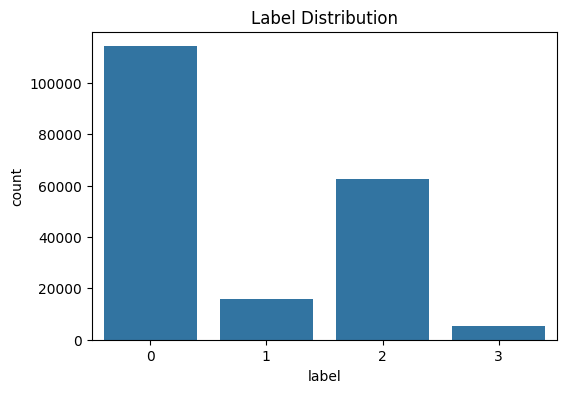

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train)
plt.title("Label Distribution")
plt.show()

### Insight
#### I observed that class 0 is much more frequent than others.This means accuracy might be slightly biased.

## - Upvote vs Downvote

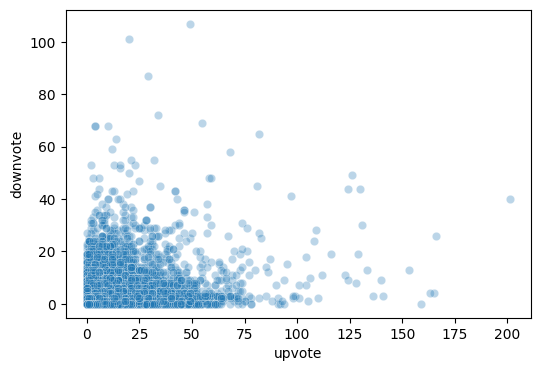

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="upvote", y="downvote", data=train, alpha=0.3)
plt.show()

### Insight
#### The scatter plot shows most values are clustered near zero, meaning most comments have low engagement.
#### But there are some outliers, which might help the model identify important comments.

## - Comment Length Distribution

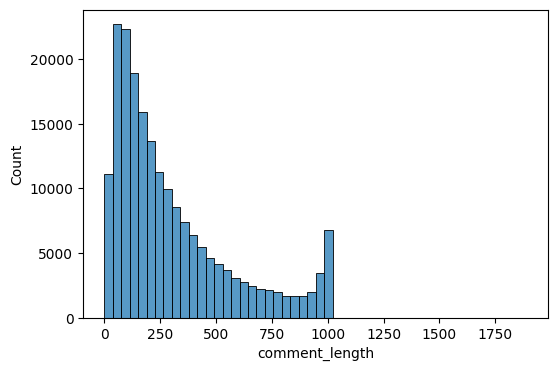

In [16]:
train["comment_length"] = train["comment"].fillna("").apply(len)
plt.figure(figsize=(6,4))
sns.histplot(train["comment_length"], bins=50)
plt.show()

### Insights
#### Most comments are short, but some are very long.So I created features like comment length and word count to capture this behavior.

# 5. Feature Engineering

#### I created additional features:
#### - Extracted year, month, day from date.
#### - Created coomment length and word count.

#### These features help capture temporal patterns and text size.

## - Converted date

In [17]:
train["created_date"] = pd.to_datetime(train["created_date"])
test["created_date"] = pd.to_datetime(test["created_date"])

## - Extracting features

In [18]:
train["year"] = train["created_date"].dt.year
train["month"] = train["created_date"].dt.month
train["day"] = train["created_date"].dt.day

test["year"] = test["created_date"].dt.year
test["month"] = test["created_date"].dt.month
test["day"] = test["created_date"].dt.day

## - Text Features

In [19]:
train["comment_length"] = train["comment"].astype(str).apply(len)
test["comment_length"] = test["comment"].astype(str).apply(len)

## - Word count

In [20]:
train["word_count"] = train["comment"].astype(str).str.split().str.len()
test["word_count"] = test["comment"].astype(str).str.split().str.len()

# 6. Feature Selection

In [21]:
num_features = [
"upvote","downvote",
"emoticon_1","emoticon_2","emoticon_3",
"if_1","if_2",
"race","religion","gender","disability",
"year","month","day",
"comment_length","word_count"
]
text_feature="comment"
y = train["label"]

# 7. Train Validation Split

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
train,
y,
test_size=0.2,
random_state=42,
stratify=y
)

# 8. Preprocessing Pipeline

#### I used ColumnTransformer to process data:
##### 1.Text → TF-IDF
##### 2.Numeric → passed as it is.


#### TF-IDF converts text into numerical form based on word importance.

In [23]:
preprocessor = ColumnTransformer(
[
("text",TfidfVectorizer(max_features=20000),text_feature),
("num","passthrough",num_features)
]
)

# 9. Model Training

## - Logistic Regression

In [24]:
log_model = Pipeline([
("prep",preprocessor),
("model",LogisticRegression(max_iter=300))
])

log_model.fit(X_train,y_train)

pred = log_model.predict(X_val)

print("Logistic Regression Accuracy:",accuracy_score(y_val,pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8446969696969697


## - Random Forest

In [25]:
rf_model = Pipeline([
("prep",preprocessor),
("model",RandomForestClassifier(n_estimators=200))
])

rf_model.fit(X_train,y_train)

pred = rf_model.predict(X_val)

print("Random Forest Accuracy:",accuracy_score(y_val,pred))

Random Forest Accuracy: 0.9012373737373738


## - XGBoost

In [26]:
xgb_model = Pipeline([
("prep",preprocessor),
("model",xgb.XGBClassifier(
n_estimators=300,
learning_rate=0.05,
max_depth=6
))
])

xgb_model.fit(X_train,y_train)

pred = xgb_model.predict(X_val)

print("XGBoost Accuracy:",accuracy_score(y_val,pred))

XGBoost Accuracy: 0.9026767676767676


## - LightGBM

In [27]:
lgb_model = Pipeline([
("prep",preprocessor),
("model",lgb.LGBMClassifier(
n_estimators=300,
learning_rate=0.05
))
])

lgb_model.fit(X_train,y_train)

pred = lgb_model.predict(X_val)

print("LightGBM Accuracy:",accuracy_score(y_val,pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 20.220320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 838800
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 15757
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.9140909090909091


## - KNN

In [28]:
knn_model = Pipeline([
("prep",preprocessor),
("model",KNeighborsClassifier())
])

knn_model.fit(X_train,y_train)

pred = knn_model.predict(X_val)

print("KNN Accuracy:", accuracy_score(y_val,pred))

KNN Accuracy: 0.8178535353535353


# 10. Model Comparison

In [29]:
models = {
"Logistic Regression":log_model,
"KNN":knn_model,
"Random Forest":rf_model,
"XGBoost":xgb_model,
"LightGBM":lgb_model
}
results = {}

for name,model in models.items():
    
    pred = model.predict(X_val)
    
    results[name] = accuracy_score(y_val,pred)

pd.DataFrame(results,index=["Accuracy"]).T.sort_values("Accuracy",ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy
LightGBM,0.914091
XGBoost,0.902677
Random Forest,0.901237
Logistic Regression,0.844697
KNN,0.817854


# 11. Hyperparameter Tuning

##  XGBoost

In [30]:
xgb_params = {
    "model__n_estimators":[300,400],
    "model__learning_rate":[0.03,0.05,0.1],
    "model__max_depth":[4,6,8],
    "model__subsample":[0.7,0.9,1]
}

xgb_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_params,
    n_iter=4,
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train,y_train)

print("Best XGB Parameters:",xgb_search.best_params_)

xgb_pred = xgb_search.predict(X_val)

print("Tuned XGBoost Accuracy:",accuracy_score(y_val,xgb_pred))

Best XGB Parameters: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 8, 'model__learning_rate': 0.1}
Tuned XGBoost Accuracy: 0.9101515151515152


##  LightGBM

In [31]:
lgb_model = Pipeline([
("prep", preprocessor),
("model", lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=50,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
))
])

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_val)

print("Tuned LightGBM Accuracy:", accuracy_score(y_val, lgb_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 23.405187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 838800
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 15757
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuned LightGBM Accuracy: 0.9157070707070707


# 12. Selecting Best Tuned Model

In [32]:
final_model = lgb_model
final_model.fit(X_train, y_train)
test_predictions = final_model.predict(test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 24.465697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 838800
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 15757
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# 13. Submission

In [33]:
submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

submission["label"] = test_predictions

submission.to_csv("submission.csv",index=False)